In [77]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

In [78]:
file = '~/Desktop/Dont Know/customer_segmentation/dataset/customer_segmentation_data.csv'
df=pd.read_csv(file)

In [79]:
display(df.head())
display(df.tail())

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16
999,1000,36,Female,90420,7,2,31,Groceries,669.26


In [80]:
df.isnull().sum()

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   str    
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   str    
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), str(2)
memory usage: 84.5 KB


In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df=df.drop(columns=['id', 'gender', 'preferred_category', 'last_purchase_amount', 'membership_years'])

In [84]:
df.head()

,age,income,spending_score,purchase_frequency
0,38,99342,90,24
1,21,78852,60,42
2,60,126573,30,28
3,40,47099,74,5
4,65,140621,21,25


In [100]:
scaler=sk.preprocessing.StandardScaler()
df=scaler.fit_transform(df)

In [101]:
elbow=[]

for k in range(1,10):
    kmeans=sk.cluster.KMeans(n_clusters=k, random_state=77, n_init=10)
    kmeans.fit(df)
    elbow.append(kmeans.inertia_)

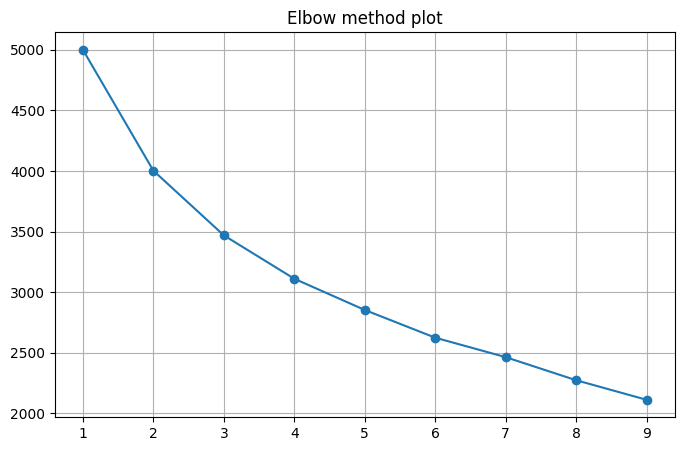

In [102]:
plt.figure(figsize=(8,5))
plt.plot(range(1,10), elbow, marker='o')
plt.title('Elbow method plot')
plt.grid(True)

In [103]:
for k in range(2,6):
    kmeans=sk.cluster.KMeans(n_clusters=k, random_state=77, n_init=10)
    pred=kmeans.fit_predict(df)
    score=sk.metrics.silhouette_score(df,pred)
    print(f'for k={k} silhouette score is {score}')

for k=2 silhouette score is 0.20810907912021157
for k=3 silhouette score is 0.20017175664952683
for k=4 silhouette score is 0.21622549242286176
for k=5 silhouette score is 0.2089903967107249


In [104]:
kmeans=sk.cluster.KMeans(n_clusters=4, random_state=77, n_init=10)
labels=kmeans.fit_predict(df)

In [105]:
pca=sk.decomposition.PCA(n_components=2, random_state=77)
X=pca.fit_transform(df)
centers=pca.transform(kmeans.cluster_centers_)

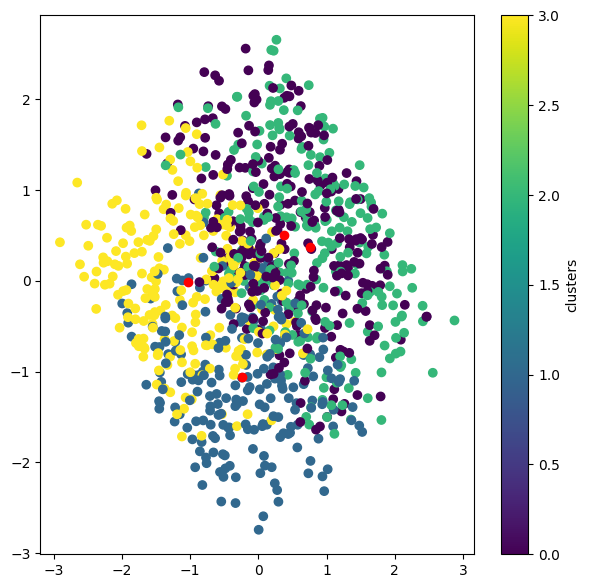

In [106]:
plt.figure(figsize=(7,7))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.colorbar(label='clusters')
plt.scatter(centers[:,0], centers[:,1], c='red', label='Centroids')